In [ ]:

# Credit Card Fraud Detection Using Random Forest


In [19]:

#Step 1 — Project Setup


In [3]:
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn joblib


Note: you may need to restart the kernel to use updated packages.


In [21]:
#Import libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE

import joblib

import warnings
warnings.filterwarnings("ignore")

In [22]:
#Configure visualization

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)

In [23]:
#load Dataset

df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [24]:
#Confirmation for dataset load correctly

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 284807
Columns: 31


In [26]:
#Check the column names

print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [20]:

#Step 2 — Data Understanding & Data Quality Analysis


In [27]:
#Check missing values

missing_values = df.isnull().sum()
missing_values

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [28]:
#Check duplicate records

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1081


In [29]:
#Calculate duplicate percentage

duplicate_percentage = (
    duplicate_count / len(df)
) * 100

print(
    f"Duplicate percentage: {duplicate_percentage:.4f}%"
)

Duplicate percentage: 0.3796%


In [31]:
#Check the target variable
# 0 → Legitimate
# 1 → Fraud

df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [32]:
#Calculate target percentages
# 0 → Legitimate
# 1 → Fraud

class_percentage = (
    df["Class"]
    .value_counts(normalize=True)
    * 100
)

class_percentage

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

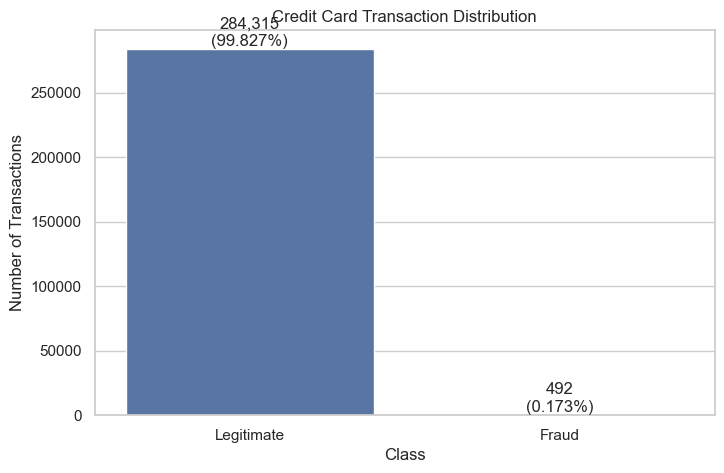

In [35]:
#Put Visualize the class distribution with percentages on the chart

class_counts = df["Class"].value_counts()

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("Credit Card Transaction Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

for i, value in enumerate(class_counts.values):
    percentage = value / len(df) * 100
    
    plt.text(
        i,
        value,
        f"{value:,}\n({percentage:.3f}%)",
        ha="center",
        va="bottom"
    )

plt.show()

In [39]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [40]:
print(
    "Minimum Amount:",
    df["Amount"].min()
)

print(
    "Maximum Amount:",
    df["Amount"].max()
)

print(
    "Average Amount:",
    df["Amount"].mean()
)

print(
    "Median Amount:",
    df["Amount"].median()
)

Minimum Amount: 0.0
Maximum Amount: 25691.16
Average Amount: 88.34961925093133
Median Amount: 22.0


In [41]:
#Compare transaction amounts by class

df.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Class,,,,,
0,284315,88.291022,22.00,0.0,25691.16
1,492,122.211321,9.25,0.0,2125.87


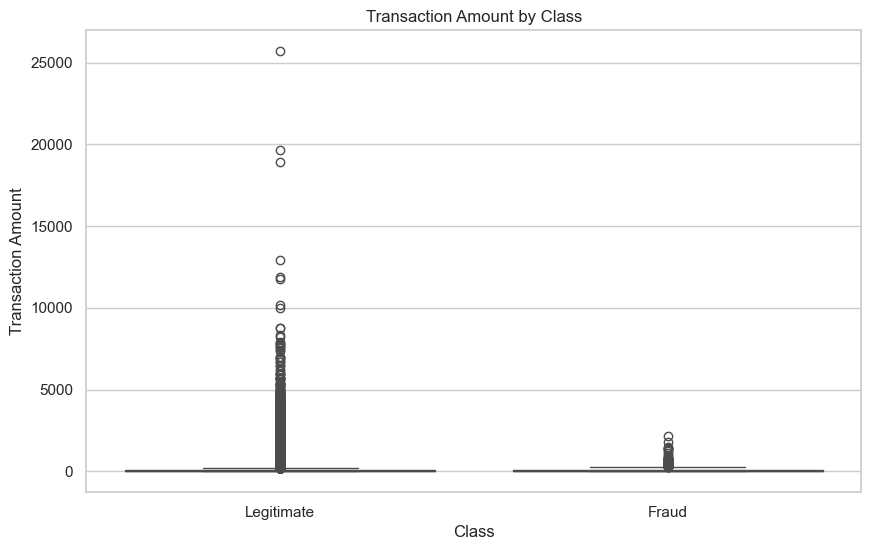

In [42]:
#Visualize amount by class

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Transaction Amount")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.show()

In [46]:
#Check whether all features are numeric

df.select_dtypes(
    include="number"
).shape

(284807, 31)

In [47]:
non_numeric_columns = df.select_dtypes(
    exclude="number"
).columns

print(non_numeric_columns.tolist())

[]


In [49]:

## Step 3 — Exploratory Data Analysis (EDA)


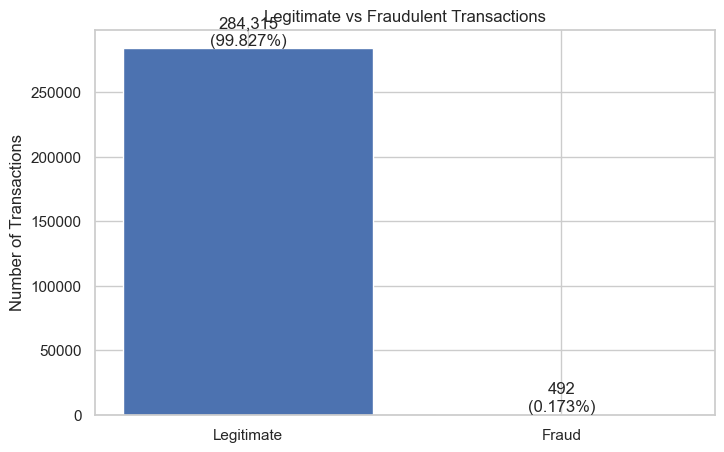

In [50]:
#Fraud vs legitimate transactions

class_counts = df["Class"].value_counts()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    ["Legitimate", "Fraud"],
    [
        class_counts[0],
        class_counts[1]
    ]
)

plt.title("Legitimate vs Fraudulent Transactions")
plt.ylabel("Number of Transactions")

for bar, count in zip(bars, [class_counts[0], class_counts[1]]):
    percentage = count / len(df) * 100

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.3f}%)",
        ha="center",
        va="bottom"
    )

plt.show()

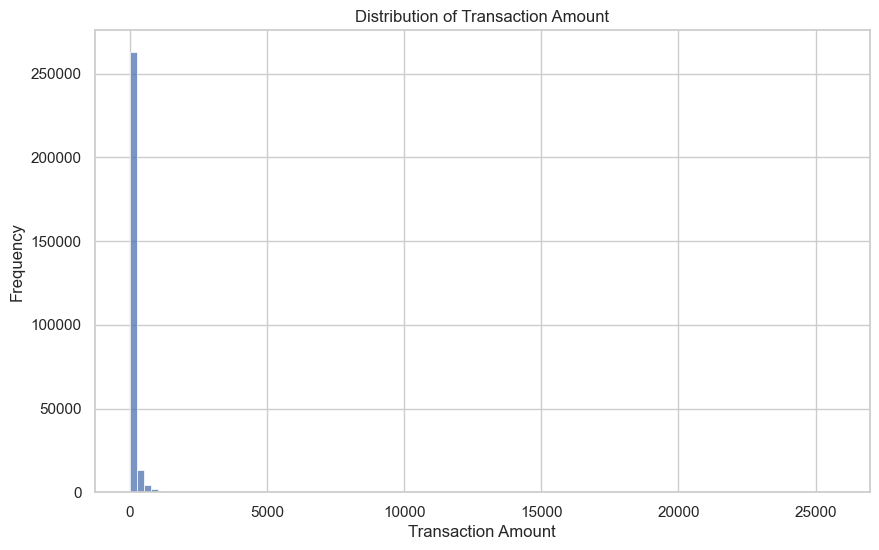

In [51]:
#Transaction amount distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Amount",
    bins=100
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

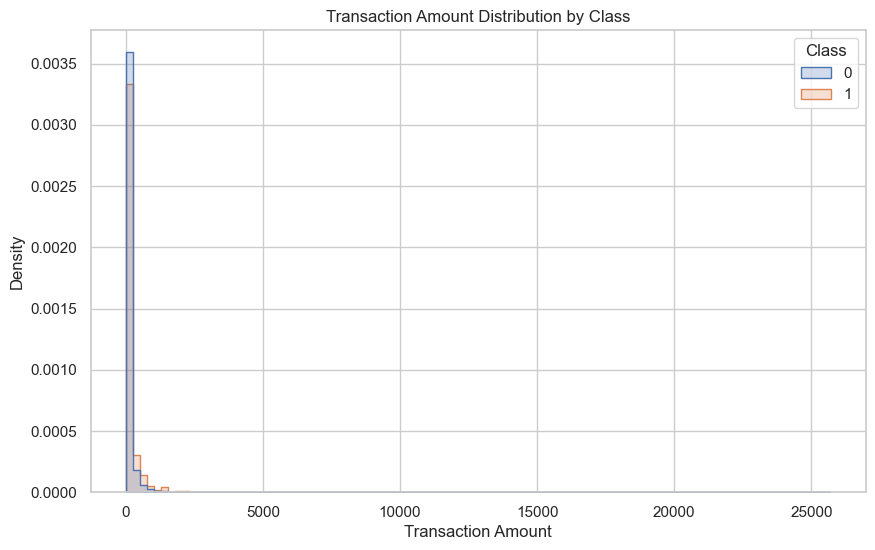

In [52]:
#Transaction amount — legitimate vs fraud

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")

plt.show()

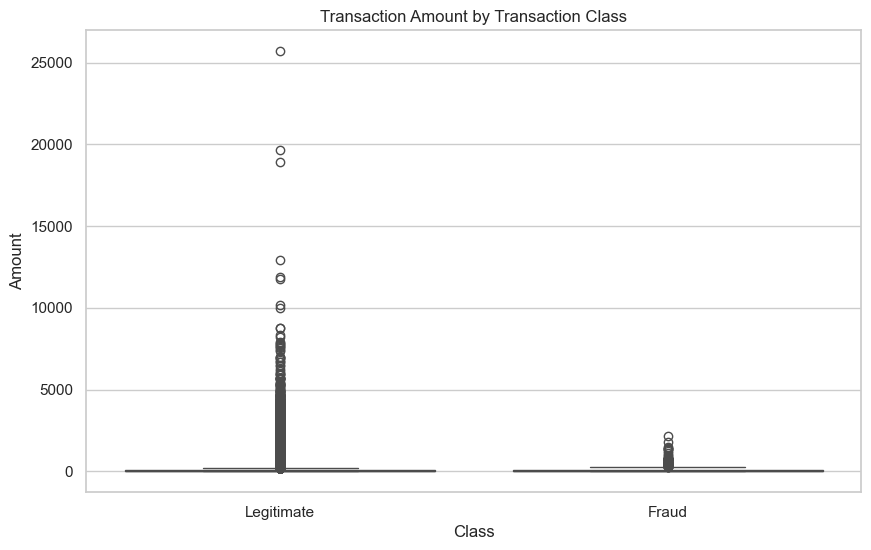

In [57]:
#Boxplot of transaction amount

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Transaction Class")
plt.xlabel("Class")
plt.ylabel("Amount")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.show()

In [56]:
#Compare statistical values

amount_statistics = df.groupby("Class")["Amount"].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"
])

amount_statistics

,count,mean,median,std,min,max
Class,,,,,,
0,284315,88.291022,22.00,250.105092,0.0,25691.16
1,492,122.211321,9.25,256.683288,0.0,2125.87


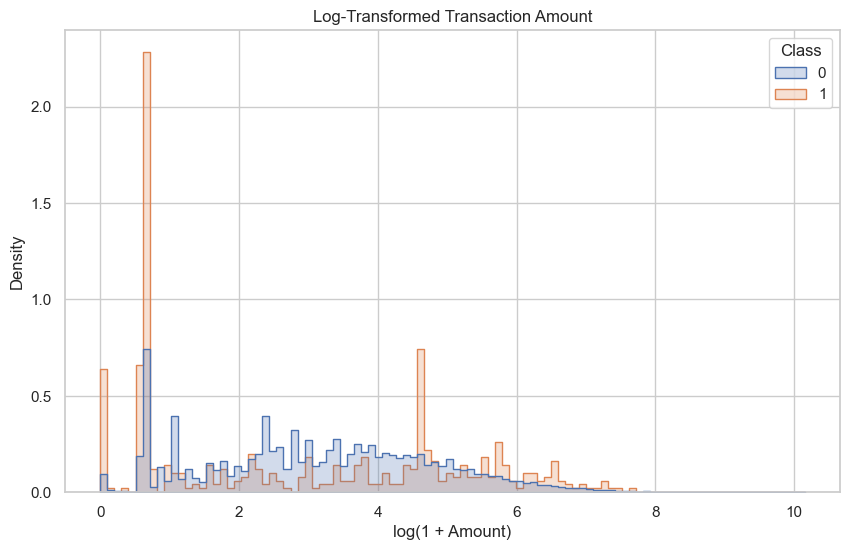

In [61]:
#Log transformation for visualization

df["Amount_Log"] = np.log1p(df["Amount"])

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Amount_Log",
    hue="Class",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Log-Transformed Transaction Amount")
plt.xlabel("log(1 + Amount)")
plt.ylabel("Density")

plt.show()

In [64]:
#Analyze the Time feature
df["Time"].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

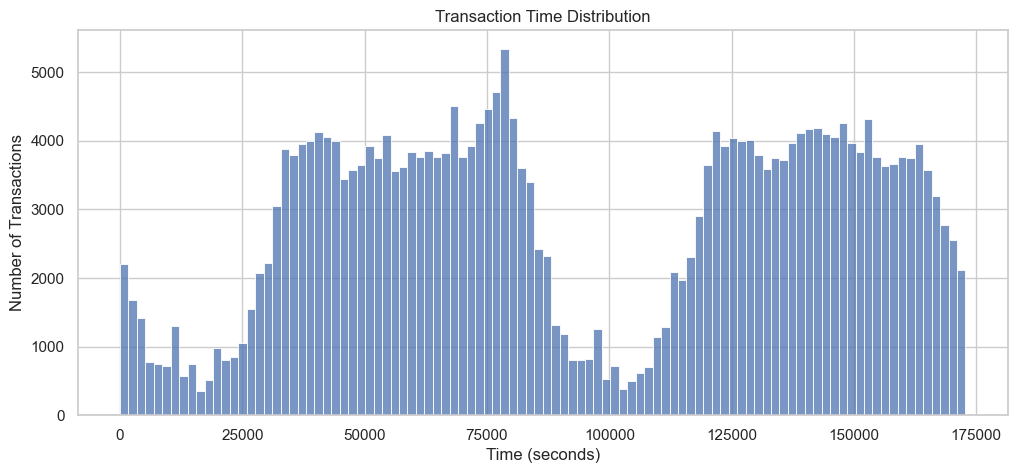

In [63]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="Time",
    bins=100
)

plt.title("Transaction Time Distribution")
plt.xlabel("Time (seconds)")
plt.ylabel("Number of Transactions")

plt.show()

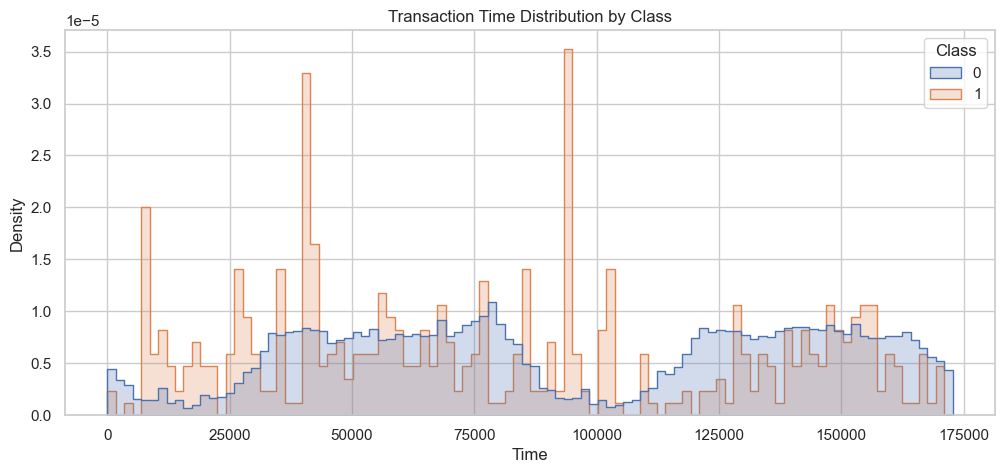

In [65]:
#Time distribution by fraud class

plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Time Distribution by Class")
plt.xlabel("Time")
plt.ylabel("Density")

plt.show()

In [66]:
#Fraud rate over time

df["Time_Bin"] = pd.cut(
    df["Time"],
    bins=20
)

In [67]:
fraud_rate_by_time = (
    df.groupby(
        "Time_Bin",
        observed=True
    )["Class"]
    .mean()
)

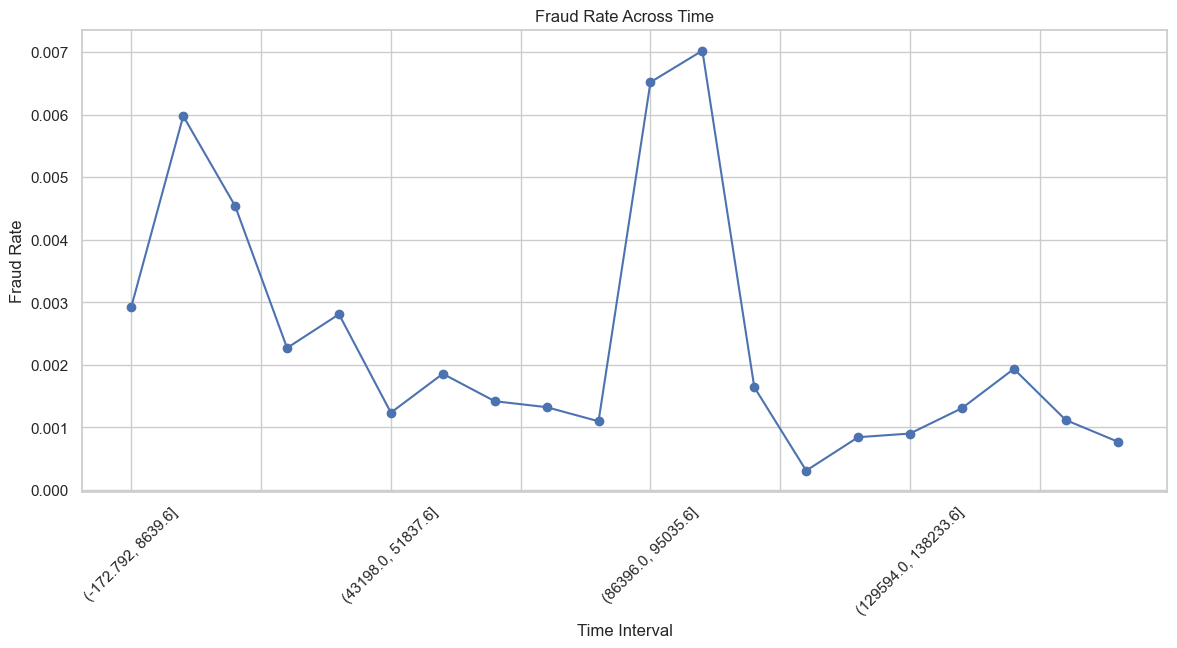

In [68]:
plt.figure(figsize=(14, 6))

fraud_rate_by_time.plot(
    marker="o"
)

plt.title("Fraud Rate Across Time")
plt.xlabel("Time Interval")
plt.ylabel("Fraud Rate")

plt.xticks(rotation=45)

plt.show()

In [69]:
# Analyze V1–V28
v_features = [
    f"V{i}" for i in range(1, 29)
]

print(v_features)

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']


In [71]:
#Distribution of V features
selected_features = [
    "V1",
    "V2",
    "V3",
    "V10",
    "V12",
    "V14",
    "V17"
]

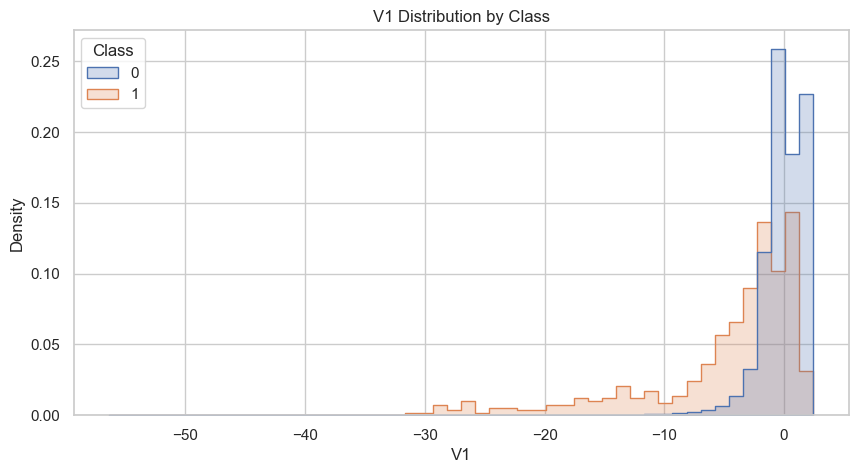

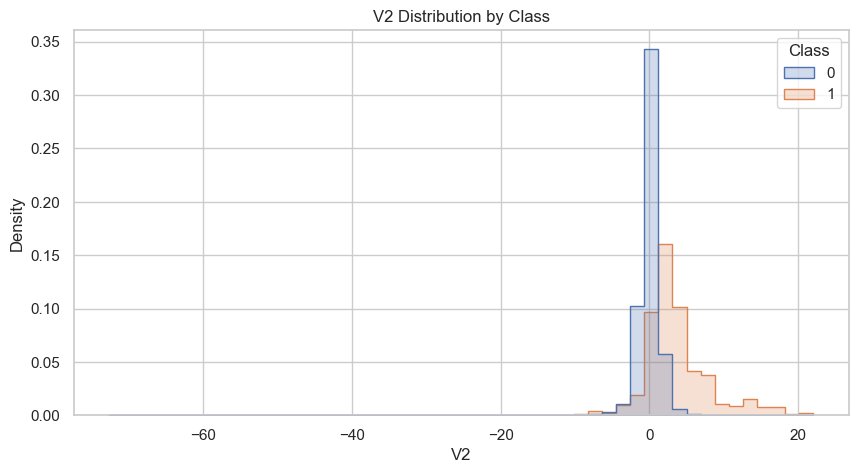

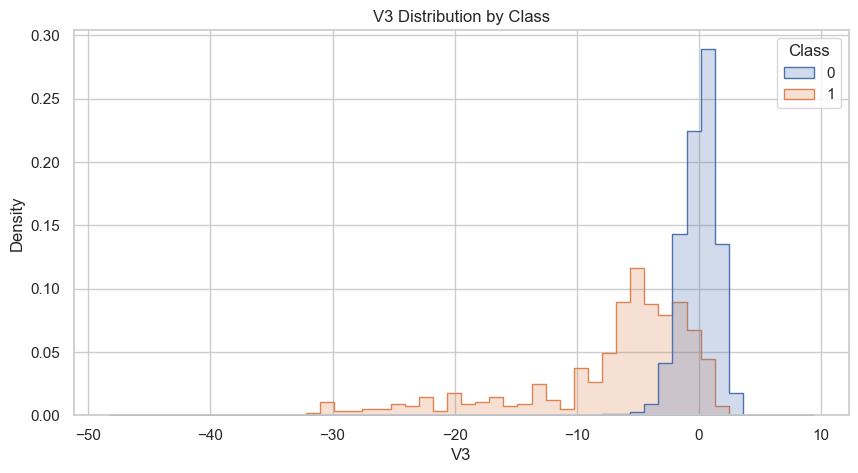

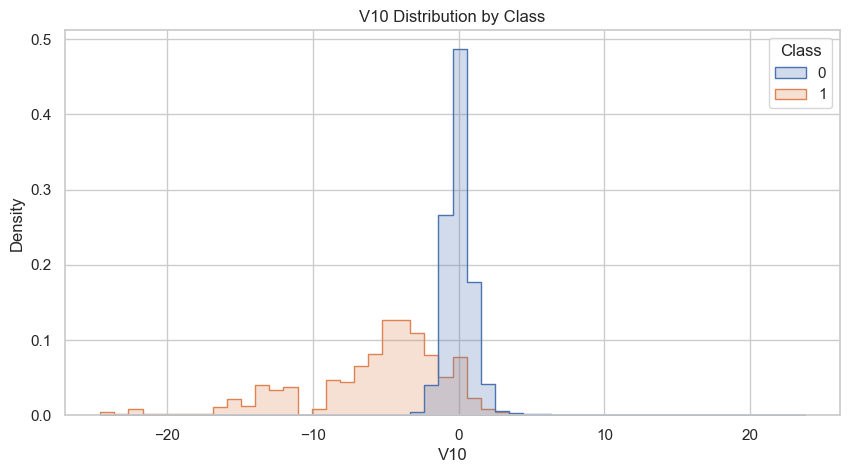

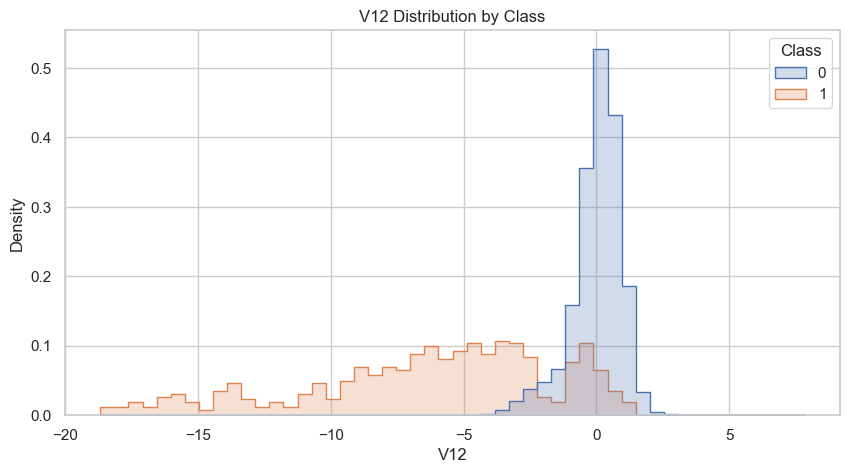

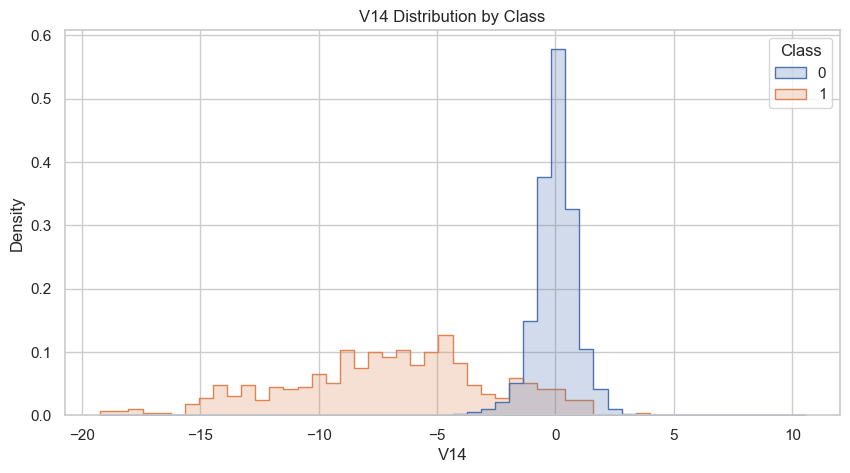

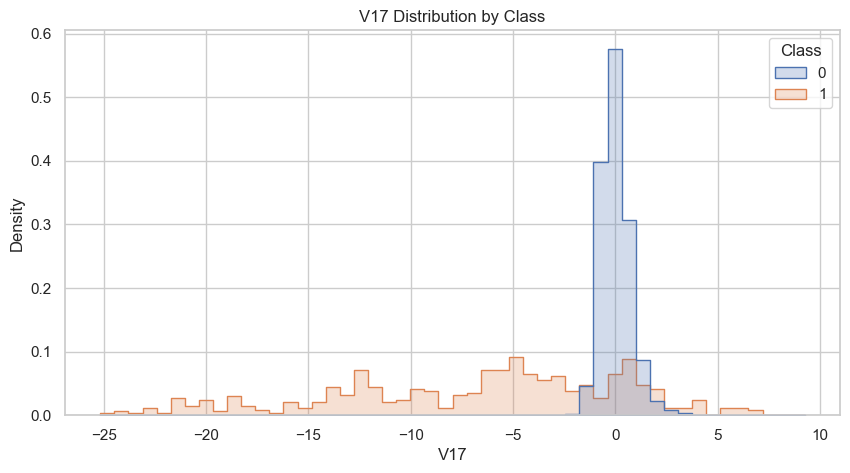

In [72]:
for feature in selected_features:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        data=df,
        x=feature,
        hue="Class",
        bins=50,
        element="step",
        stat="density",
        common_norm=False
    )

    plt.title(
        f"{feature} Distribution by Class"
    )

    plt.show()

In [73]:

## Step 4 — Data Preprocessing


In [76]:
#Train/Test Split

from sklearn.model_selection import train_test_split

In [78]:
#Separate X and y
X = df.drop("Class", axis=1)
y = df["Class"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 32)
y shape: (284807,)


In [79]:
#Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [80]:
#Check the shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (227845, 32)
X_test : (56962, 32)
y_train: (227845,)
y_test : (56962,)


In [82]:
#Check the training class distribution
print("Training set class distribution:")
print(y_train.value_counts())

Training set class distribution:
Class
0    227451
1       394
Name: count, dtype: int64


In [83]:
print("\nTraining set percentage:")
print(
    y_train.value_counts(normalize=True) * 100
)


Training set percentage:
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64


In [85]:
#Check the testing class distribution
print("Testing set class distribution:")
print(y_test.value_counts())
print("\nTesting set percentage:")
print(
    y_test.value_counts(normalize=True) * 100
)

Testing set class distribution:
Class
0    56864
1       98
Name: count, dtype: int64

Testing set percentage:
Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64


In [87]:
#Verify no train/test overlap
train_indices = set(X_train.index)
test_indices = set(X_test.index)

overlap = train_indices.intersection(test_indices)

print("Overlapping records:", len(overlap))

Overlapping records: 0


In [88]:
#Check missing values after splitting
print(
    "Missing values in training:",
    X_train.isnull().sum().sum()
)

print(
    "Missing values in testing:",
    X_test.isnull().sum().sum()
)

Missing values in training: 0
Missing values in testing: 0


In [89]:

#Step 5 — Random Forest Baseline


In [95]:
df = df.drop(
    columns=["Amount_Log", "Time_Bin"],
    errors="ignore"
)

In [96]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [105]:
#Import Random Forest
from sklearn.ensemble import RandomForestClassifier

#Create the Random Forest model
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

In [109]:
rf_baseline.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [111]:
#Generate predictions
y_pred_baseline = rf_baseline.predict(X_test)
print(y_pred_baseline[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [112]:
#Generate fraud probabilities
y_probability_baseline = (
    rf_baseline.predict_proba(X_test)[:, 1]
)
print(y_probability_baseline[:20])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [114]:
#Check minimum and maximum probability
print("Minimum fraud probability:",
      y_probability_baseline.min())

print("Maximum fraud probability:",
      y_probability_baseline.max())

Minimum fraud probability: 0.0
Maximum fraud probability: 1.0


In [115]:
#Check how many probabilities are exactly zero
zero_probabilities = (
    y_probability_baseline == 0
).sum()

print(
    "Number of zero probabilities:",
    zero_probabilities
)

print(
    "Total test transactions:",
    len(y_probability_baseline)
)

Number of zero probabilities: 55658
Total test transactions: 56962


In [117]:
#Check probabilities for actual fraud transactions
fraud_probabilities = y_probability_baseline[
    y_test.values == 1
]

print(
    fraud_probabilities[:20]
)

print(
    "Average fraud probability for actual fraud:",
    fraud_probabilities.mean()
)

[0.95 0.97 0.75 0.41 0.89 0.95 0.74 0.97 0.84 0.97 0.41 0.3  0.86 0.93
 0.73 1.   1.   0.14 0.33 0.85]
Average fraud probability for actual fraud: 0.7059183673469388


In [118]:
#Calculate the metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)

precision = precision_score(
    y_test,
    y_pred_baseline
)

recall = recall_score(
    y_test,
    y_pred_baseline
)

f1 = f1_score(
    y_test,
    y_pred_baseline
)

roc_auc = roc_auc_score(
    y_test,
    y_probability_baseline
)

pr_auc = average_precision_score(
    y_test,
    y_probability_baseline
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

Accuracy : 0.9995
Precision: 0.9605
Recall   : 0.7449
F1 Score : 0.8391
ROC-AUC  : 0.9529
PR-AUC   : 0.8542


In [119]:
cm = confusion_matrix(
    y_test,
    y_pred_baseline
)

tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 56861
False Positives: 3
False Negatives: 25
True Positives : 73


In [120]:
print("\nFraud transactions in test set:", tp + fn)
print("Fraud detected:", tp)
print("Fraud missed:", fn)


Fraud transactions in test set: 98
Fraud detected: 73
Fraud missed: 25


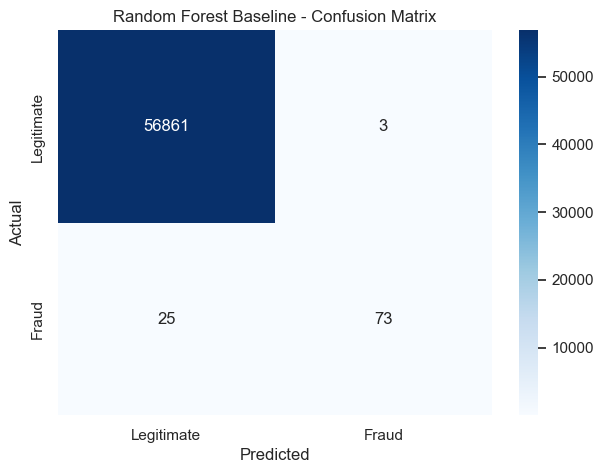

In [121]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Random Forest Baseline - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()